In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, recall_score, precision_score
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../data/dataset.csv')
df.columns = [i for i in range(df.shape[1])]
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.421356,0.739248,-4.477836e-07,0.499869,0.790821,-0.072789,0.576526,0.847355,-0.136061,0.559314,...,0.317726,0.782616,-0.189356,0.322156,0.793244,-0.184447,0.320762,0.728276,-0.183729,Fist
1,0.423885,0.683504,-4.086668e-07,0.513703,0.732933,-0.062486,0.589710,0.789869,-0.118196,0.581930,...,0.348199,0.717782,-0.181021,0.355230,0.727275,-0.172041,0.356873,0.668997,-0.166336,Fist
2,0.222563,0.721714,-1.384991e-07,0.319733,0.748246,-0.016055,0.379836,0.802069,-0.055467,0.394175,...,0.279250,0.820996,-0.139297,0.268138,0.804289,-0.123883,0.263472,0.760959,-0.118240,Fist
3,0.429700,0.657637,-1.843578e-07,0.520200,0.715910,-0.068423,0.594933,0.781113,-0.129312,0.587884,...,0.348327,0.719119,-0.195347,0.358479,0.706452,-0.190109,0.361726,0.637546,-0.187473,Fist
4,0.415317,0.666260,-2.048052e-07,0.509589,0.714725,-0.064314,0.580510,0.769789,-0.125224,0.582843,...,0.359190,0.692947,-0.193770,0.364375,0.700751,-0.185800,0.361429,0.647072,-0.180661,Fist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.522856,0.666141,3.867975e-03,0.484317,0.643087,-0.001164,0.444005,0.609692,-0.010661,0.413217,...,0.580504,0.547487,-0.017480,0.573985,0.579325,-0.002394,0.566742,0.582491,-0.008968,Right
2996,0.397712,0.648728,-1.950509e-03,0.341115,0.637273,-0.007324,0.310683,0.609777,-0.022278,0.270957,...,0.439262,0.554703,-0.012464,0.444291,0.573824,-0.007459,0.429253,0.587805,-0.004159,Right
2997,0.571119,0.689680,9.118480e-03,0.514874,0.629744,-0.009522,0.487934,0.562359,-0.020740,0.475149,...,0.627768,0.606138,0.007414,0.626104,0.615922,0.007002,0.621437,0.639661,0.011038,Right
2998,0.515157,0.680776,-2.906571e-03,0.557678,0.639715,0.006373,0.589312,0.573929,-0.006797,0.618526,...,0.423135,0.509115,-0.028623,0.426099,0.555258,-0.025814,0.440126,0.575659,-0.025923,Right


In [3]:
df = df.rename(columns={63: 'Output'})
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,Output
0,0.421356,0.739248,-4.477836e-07,0.499869,0.790821,-0.072789,0.576526,0.847355,-0.136061,0.559314,...,0.317726,0.782616,-0.189356,0.322156,0.793244,-0.184447,0.320762,0.728276,-0.183729,Fist
1,0.423885,0.683504,-4.086668e-07,0.513703,0.732933,-0.062486,0.589710,0.789869,-0.118196,0.581930,...,0.348199,0.717782,-0.181021,0.355230,0.727275,-0.172041,0.356873,0.668997,-0.166336,Fist
2,0.222563,0.721714,-1.384991e-07,0.319733,0.748246,-0.016055,0.379836,0.802069,-0.055467,0.394175,...,0.279250,0.820996,-0.139297,0.268138,0.804289,-0.123883,0.263472,0.760959,-0.118240,Fist
3,0.429700,0.657637,-1.843578e-07,0.520200,0.715910,-0.068423,0.594933,0.781113,-0.129312,0.587884,...,0.348327,0.719119,-0.195347,0.358479,0.706452,-0.190109,0.361726,0.637546,-0.187473,Fist
4,0.415317,0.666260,-2.048052e-07,0.509589,0.714725,-0.064314,0.580510,0.769789,-0.125224,0.582843,...,0.359190,0.692947,-0.193770,0.364375,0.700751,-0.185800,0.361429,0.647072,-0.180661,Fist
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.522856,0.666141,3.867975e-03,0.484317,0.643087,-0.001164,0.444005,0.609692,-0.010661,0.413217,...,0.580504,0.547487,-0.017480,0.573985,0.579325,-0.002394,0.566742,0.582491,-0.008968,Right
2996,0.397712,0.648728,-1.950509e-03,0.341115,0.637273,-0.007324,0.310683,0.609777,-0.022278,0.270957,...,0.439262,0.554703,-0.012464,0.444291,0.573824,-0.007459,0.429253,0.587805,-0.004159,Right
2997,0.571119,0.689680,9.118480e-03,0.514874,0.629744,-0.009522,0.487934,0.562359,-0.020740,0.475149,...,0.627768,0.606138,0.007414,0.626104,0.615922,0.007002,0.621437,0.639661,0.011038,Right
2998,0.515157,0.680776,-2.906571e-03,0.557678,0.639715,0.006373,0.589312,0.573929,-0.006797,0.618526,...,0.423135,0.509115,-0.028623,0.426099,0.555258,-0.025814,0.440126,0.575659,-0.025923,Right


In [4]:
X = df.iloc[:, :-1]
print("Features shape =", X.shape)

Y = df.iloc[:, -1]
print("Labels shape =", Y.shape)

Features shape = (3000, 63)
Labels shape = (3000,)


In [5]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
svm = SVC(C=10, gamma=0.1, kernel='rbf')
svm.fit(x_train, y_train)

SVC(C=10, gamma=0.1)

In [6]:
y_pred = svm.predict(x_test)
y_pred

array(['Fist', 'Like', 'Palm', 'Right', 'Right', 'Pointing', 'Pointing',
       'Left', 'Palm', 'Pointing', 'Palm', 'Left', 'Fist', 'Fist', 'Palm',
       'Pointing', 'Like', 'Left', 'Fist', 'Right', 'Right', 'Left',
       'Like', 'Like', 'Right', 'Fist', 'Like', 'Fist', 'Like', 'Fist',
       'Right', 'Palm', 'Pointing', 'Like', 'Like', 'Left', 'Fist',
       'Like', 'Pointing', 'Palm', 'Like', 'Left', 'Left', 'Fist', 'Left',
       'Fist', 'Right', 'Like', 'Pointing', 'Fist', 'Like', 'Like',
       'Left', 'Pointing', 'Left', 'Right', 'Pointing', 'Left',
       'Pointing', 'Pointing', 'Pointing', 'Right', 'Right', 'Left',
       'Pointing', 'Fist', 'Palm', 'Fist', 'Pointing', 'Palm', 'Palm',
       'Like', 'Like', 'Right', 'Like', 'Left', 'Fist', 'Like', 'Palm',
       'Palm', 'Like', 'Fist', 'Left', 'Right', 'Left', 'Right', 'Fist',
       'Left', 'Palm', 'Left', 'Palm', 'Like', 'Left', 'Like', 'Fist',
       'Fist', 'Left', 'Left', 'Left', 'Fist', 'Right', 'Right', 'Left',
       

In [7]:
cf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
precision = precision_score(y_test, y_pred, average='micro')
f1, recall, precision

(0.9683333333333334, 0.9683333333333334, 0.9683333333333334)

<Axes: title={'center': 'Confusion Matrix - American Sign Language'}>

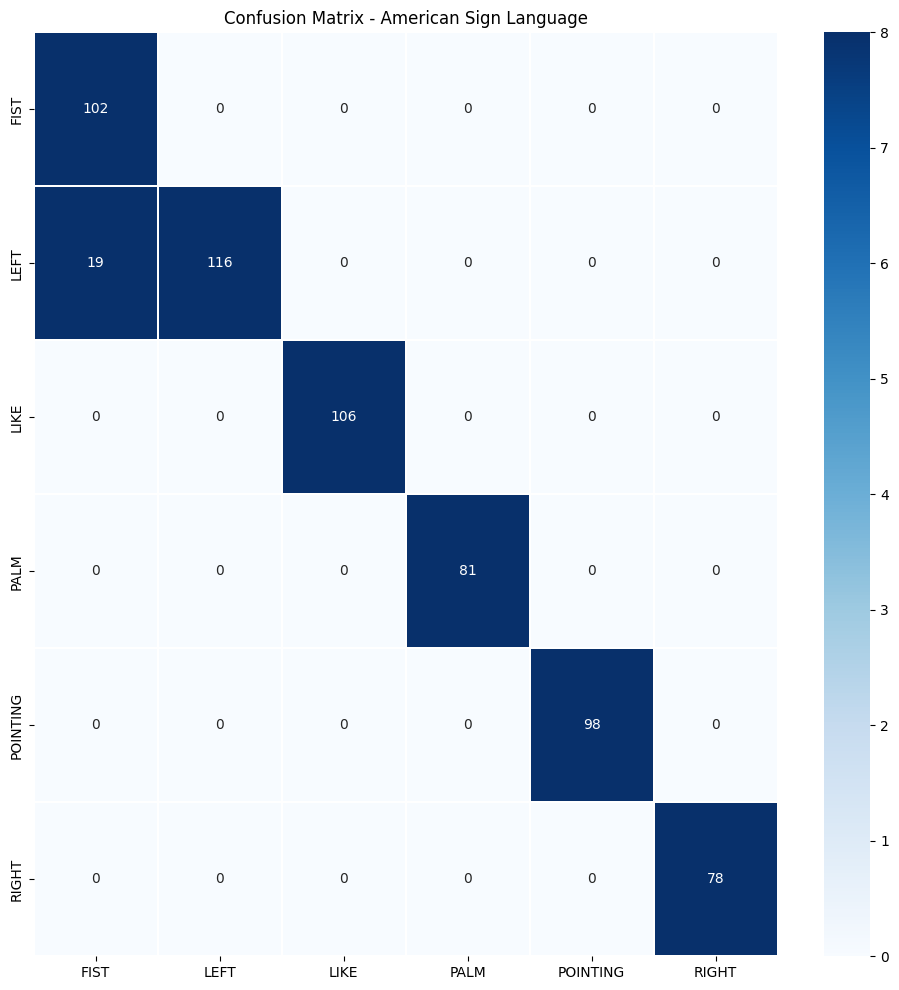

In [8]:
labels = sorted(list(set(df['Output'])))
labels = [x.upper() for x in labels]

fig, ax = plt.subplots(figsize=(12, 12))

ax.set_title("Confusion Matrix - American Sign Language")

maping = sns.heatmap(cf_matrix, 
                     annot=True,
                     cmap = plt.cm.Blues, 
                     linewidths=.2,
                     xticklabels=labels,
                     yticklabels=labels, vmax=8,
                     fmt='g',
                     ax=ax
                    )
maping

In [10]:
import pickle

# save model
with open('../models/hand_gesture_svm.pkl','wb') as f:
    pickle.dump(svm,f)